Lese CASSY-2 Datei:  1L_richtig.labx


kappa is: 1.37+/-0.10


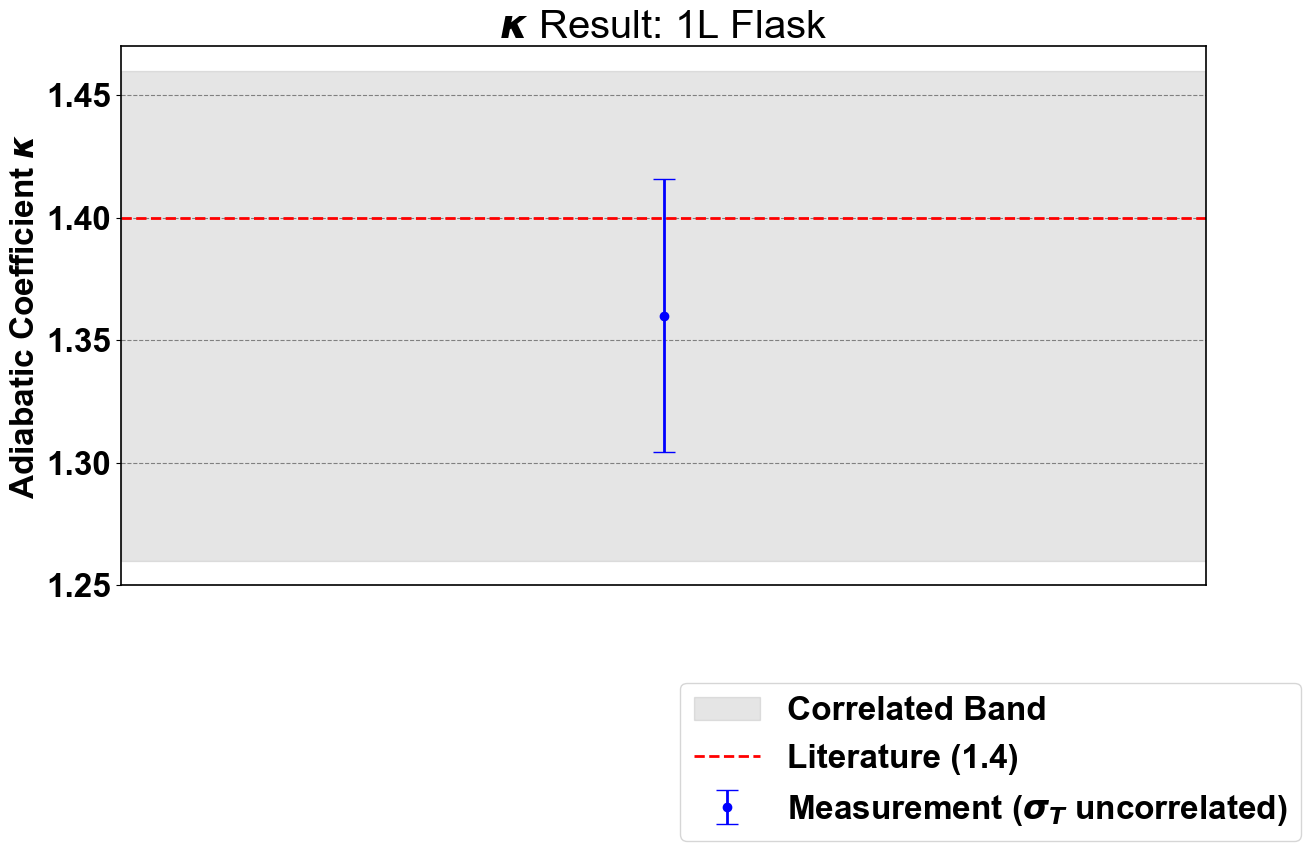

In [7]:
from praktikum import cassy
from praktikum import analyse
import numpy as np
import matplotlib.pyplot as plt
from uncertainties import ufloat
#---settings for plots---
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0
#---loading the data and plotting---
inputfile = '1L_richtig.labx'
data = cassy.CassyDaten(inputfile)
t = data.messung(1).datenreihe('t').werte
P = data.messung(1).datenreihe('p_A1').werte
plt.scatter(t,P, label='Pressure $p$', marker='.', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Pressure (hPa)')
plt.title('Pressure vs Time for 1L flask')
plt.legend()
plt.legend(loc='upper right')
plt.grid(color='gray', linestyle='--')
plt.savefig('pressure_1L.pdf', dpi=300)
#---calculating volume---

def kappa(m, V, p, D, T):
    return 64*m*V/(p * D**4 * T**2)

m = ufloat(16.433, 0.162)
p = ufloat(988.6* 100,130)
D = ufloat(15.84, 0.252)
T = ufloat(0.385, 0.0079)
t_1 = ufloat(42,1) #first tube
t_2 = ufloat(30,1) #second tube
t_3 = ufloat(34.2,1)# third tube
d = ufloat(0.62, 0.01)#inner diameter of tube
h = ufloat(13, 0.1)#hight of the ball
V_t = np.pi * (d/2/100)**2 *(t_1+t_2+t_3)/100 
V_f = ufloat(1.14152, 0.00015) *1E-3
V_b = np.pi *(D/2/1000)**2 * h/100
V = V_t + V_b + V_f
k = kappa(m, V, p, D, T) * 1E9
print("kappa is:", k)

#---plotting the error bands---

# Data from 1L flask measurements 
kappa_mean = 1.36
sigma_uncorr = 0.0557  
sigma_total = 0.10     
lit_value = 1.400     


#---Plot the single measurement with uncorrelated error
plt.cla()
plt.errorbar(1, kappa_mean,
                yerr= sigma_uncorr,
                fmt='o',
                color='blue', 
                label=r'Measurement ($\sigma_{T}$ uncorrelated)', capsize=8)

#---Plot the correlated error 
plt.axhspan(kappa_mean - sigma_total, kappa_mean + sigma_total, 
            color='gray', alpha=0.2, label='Correlated Band')

#---Literature comparison
plt.axhline(y=lit_value, color='red', linestyle='--', label='Literature (1.4)')

plt.xticks([]) 
plt.ylabel(r"Adiabatic Coefficient $\kappa$")
plt.title(r"$\kappa$ Result: 1L Flask")
plt.legend(loc='upper left', bbox_to_anchor=(0.5, -0.15))
plt.grid(color='gray', linestyle='--')
plt.savefig('kappa_1L.pdf', bbox_inches='tight')
plt.show()


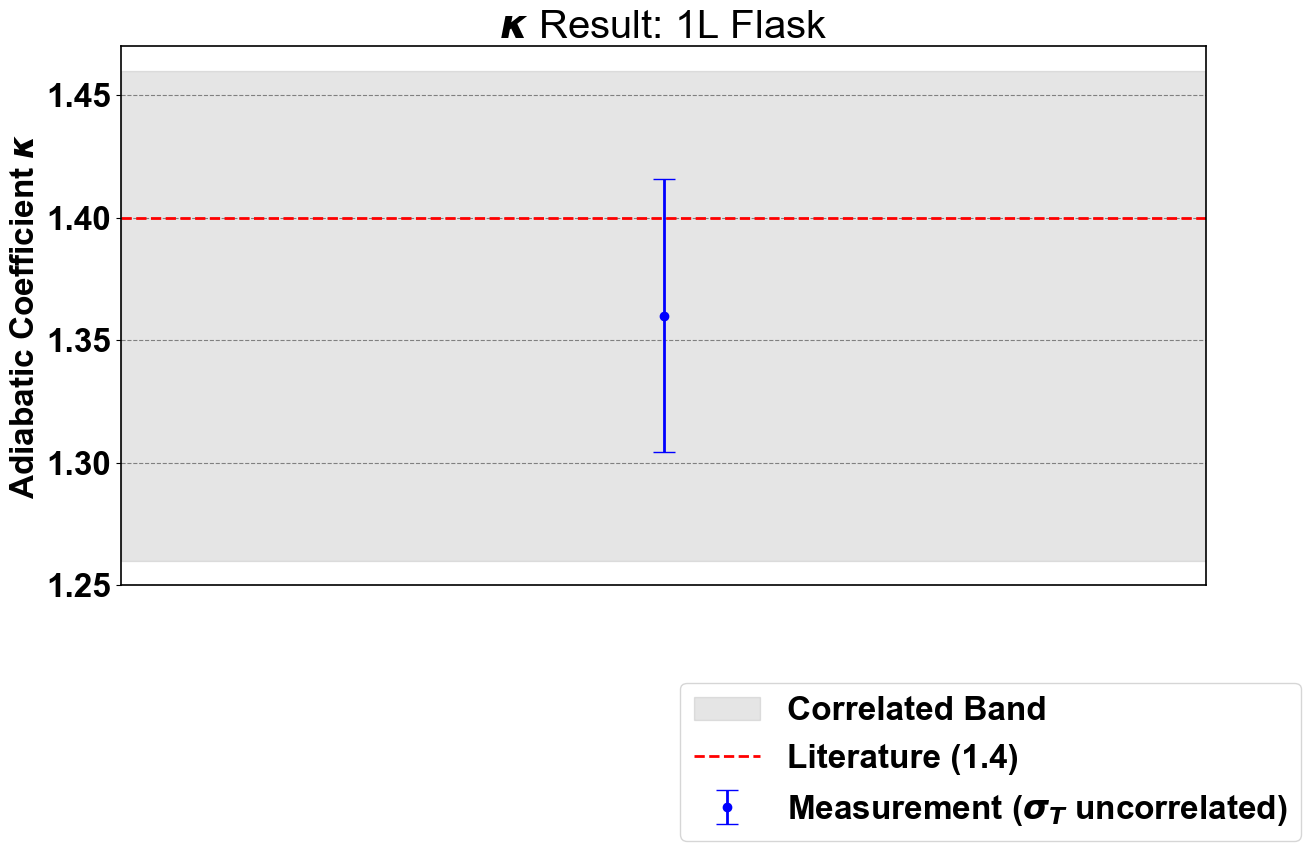

In [90]:
# Data from 1L flask measurements 
kappa_mean = 1.36
sigma_uncorr = 0.0557  
sigma_total = 0.10     
lit_value = 1.400     


#---Plot the single measurement with uncorrelated error
plt.errorbar(1, kappa_mean,
                yerr= sigma_uncorr,
                fmt='o',
                color='blue', 
                label=r'Measurement ($\sigma_{T}$ uncorrelated)', capsize=8)

#---Plot the correlated error 
plt.axhspan(kappa_mean - sigma_total, kappa_mean + sigma_total, 
            color='gray', alpha=0.2, label='Correlated Band')

#---Literature comparison
plt.axhline(y=lit_value, color='red', linestyle='--', label='Literature (1.4)')

plt.xticks([]) 
plt.ylabel(r"Adiabatic Coefficient $\kappa$")
plt.title(r"$\kappa$ Result: 1L Flask")
plt.legend(loc='upper left', bbox_to_anchor=(0.5, -0.15))
plt.grid(color='gray', linestyle='--')
plt.savefig('kappa_1L.pdf', bbox_inches='tight')
plt.show()

